// Todo

*  install, import libs
*  config data source
*  fetch hrly data for 4mts
*  calculate returns and lag returns
*  do feature selection

In [1]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from talipp.indicators import EMA
from datetime import datetime
import pytz



In [8]:
import MetaTrader5 as mt5

# display data on the MetaTrader 5 package
print("MetaTrader5 package author: ",mt5.__author__)
print("MetaTrader5 package version: ",mt5.__version__)

ticker = "GBPUSD"

# establish connection to MetaTrader 5 terminal
if not mt5.initialize():
    print("initialize() failed, error code =",mt5.last_error())
    quit()
 
# set time zone to UTC
timezone = pytz.timezone("Etc/UTC")

# create 'datetime' object in UTC time zone to avoid the implementation of a local time zone offset
utc_from = datetime(2023, 1, 1, tzinfo=timezone)
utc_to = datetime(2023, 4, 30, hour = 13, tzinfo=timezone)

# get bars from ticker within the interval in UTC time zone
rates = mt5.copy_rates_range(ticker, mt5.TIMEFRAME_H1, utc_from, utc_to)
 
# shut down connection to the MetaTrader 5 terminal
mt5.shutdown()

# create DataFrame out of the obtained data
hist_data = pd.DataFrame(rates)
# convert time in seconds into the datetime format
hist_data['time']=pd.to_datetime(hist_data['time'], unit='s')

hist_data

MetaTrader5 package author:  MetaQuotes Ltd.
MetaTrader5 package version:  5.0.4424


,time,open,high,low,close,tick_volume,spread,real_volume
0,2023-01-02 07:00:00,1.20782,1.20783,1.20736,1.20747,33,6,0
1,2023-01-02 08:00:00,1.20747,1.20768,1.20662,1.20747,293,0,0
2,2023-01-02 09:00:00,1.20747,1.20764,1.20570,1.20628,429,2,0
3,2023-01-02 10:00:00,1.20633,1.20759,1.20453,1.20454,1438,1,0
4,2023-01-02 11:00:00,1.20466,1.20567,1.20440,1.20458,1616,1,0
...,...,...,...,...,...,...,...,...
2026,2023-04-28 19:00:00,1.25803,1.25838,1.25720,1.25744,4769,2,0
2027,2023-04-28 20:00:00,1.25745,1.25753,1.25670,1.25673,3211,3,0
2028,2023-04-28 21:00:00,1.25673,1.25747,1.25611,1.25641,3573,4,0
2029,2023-04-28 22:00:00,1.25641,1.25679,1.25574,1.25676,2656,4,0


In [10]:
hist_data.describe()



,Time,Open,High,Low,Close,Volume,Spread
count,2031,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000,2031.000000
mean,2023-03-01 15:51:17.104874496,1.222095,1.223169,1.221051,1.222126,5124.252093,4.258493
min,2023-01-02 07:00:00,1.181190,1.181930,1.180300,1.181190,33.000000,0.000000
25%,2023-01-31 10:30:00,1.205460,1.206625,1.204535,1.205480,2533.000000,2.000000
50%,2023-03-01 14:00:00,1.222020,1.223040,1.220950,1.222150,4605.000000,4.000000
75%,2023-03-30 19:30:00,1.238990,1.239785,1.238080,1.239035,6904.500000,6.000000
max,2023-04-28 23:00:00,1.258030,1.258380,1.257200,1.258040,21774.000000,17.000000
std,NaN,0.018111,0.018006,0.018216,0.018128,3393.492774,2.972227


In [9]:

hist_data = hist_data.drop(columns=['real_volume'])
hist_data.rename(columns={'time':'Time', 'open':'Open', 'high':'High', 'low':'Low', 'close':'Close', 'tick_volume':'Volume', 'spread':'Spread'}, inplace=True)
hist_data.set_index('Time', inplace=True)
hist_data.head()

,Time,Open,High,Low,Close,Volume,Spread
0,2023-01-02 07:00:00,1.20782,1.20783,1.20736,1.20747,33,6
1,2023-01-02 08:00:00,1.20747,1.20768,1.20662,1.20747,293,0
2,2023-01-02 09:00:00,1.20747,1.20764,1.20570,1.20628,429,2
3,2023-01-02 10:00:00,1.20633,1.20759,1.20453,1.20454,1438,1
4,2023-01-02 11:00:00,1.20466,1.20567,1.20440,1.20458,1616,1


In [12]:
hist_data['Returns'] = hist_data['Close'].pct_change()
hist_data.head()

,Open,High,Low,Close,Volume,Spread,Returns
Time,,,,,,,
2023-01-02 07:00:00,1.20782,1.20783,1.20736,1.20747,33,6,NaN
2023-01-02 08:00:00,1.20747,1.20768,1.20662,1.20747,293,0,0.000000
2023-01-02 09:00:00,1.20747,1.20764,1.20570,1.20628,429,2,-0.000986
2023-01-02 10:00:00,1.20633,1.20759,1.20453,1.20454,1438,1,-0.001442
2023-01-02 11:00:00,1.20466,1.20567,1.20440,1.20458,1616,1,0.000033


In [13]:
hist_data['Lagged_Returns'] = hist_data['Returns'].shift(1)
hist_data.dropna(inplace=True)
hist_data.head()

,Open,High,Low,Close,Volume,Spread,Returns,Lagged_Returns
Time,,,,,,,,
2023-01-02 07:00:00,1.20782,1.20783,1.20736,1.20747,33,6,NaN,NaN
2023-01-02 08:00:00,1.20747,1.20768,1.20662,1.20747,293,0,0.000000,NaN
2023-01-02 09:00:00,1.20747,1.20764,1.20570,1.20628,429,2,-0.000986,0.000000
2023-01-02 10:00:00,1.20633,1.20759,1.20453,1.20454,1438,1,-0.001442,-0.000986
2023-01-02 11:00:00,1.20466,1.20567,1.20440,1.20458,1616,1,0.000033,-0.001442


In [16]:
# Perform feature selection, using "Returns" as dependent variable

from sklearn.feature_selection import SelectKBest, f_regression

# Remove rows with NaN values (caused by lagged returns)
hist_data = hist_data.dropna()

# Define dependent variable (y) and independent variables (X)
y = hist_data['Returns']
X = hist_data[['Open', 'High', 'Low', 'Close', 'Volume', 'Lagged_Returns']]

# Use SelectKBest to select the best features using f_regression
selector = SelectKBest(score_func=f_regression, k='all') 
X_new = selector.fit_transform(X, y)

# Get the scores for each feature
scores = selector.scores_

# Create a DataFrame to display the features and their scores
feature_scores = pd.DataFrame({'Feature': X.columns, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print(feature_scores)

          Feature     Score
5  Lagged_Returns  9.446061
3           Close  5.324586
0            Open  2.240218
2             Low  0.237923
1            High  0.200104
4          Volume  0.040895


In [17]:
# Keep the top three most relevant features based on highest scores and drop the remaining from hist_data

# Get the top 3 features
top_features = feature_scores.nlargest(3, 'Score')['Feature'].tolist()

# Keep only the top 3 features in hist_data
hist_data = hist_data[top_features + ['Returns']]

hist_data

,Lagged_Returns,Close,Open,Returns
Time,,,,
2023-01-02 09:00:00,0.000000,1.20628,1.20747,-0.000986
2023-01-02 10:00:00,-0.000986,1.20454,1.20633,-0.001442
2023-01-02 11:00:00,-0.001442,1.20458,1.20466,0.000033
2023-01-02 12:00:00,0.000033,1.20524,1.20457,0.000548
2023-01-02 13:00:00,0.000548,1.20515,1.20524,-0.000075
...,...,...,...,...
2023-04-28 19:00:00,0.001242,1.25744,1.25803,-0.000477
2023-04-28 20:00:00,-0.000477,1.25673,1.25745,-0.000565
2023-04-28 21:00:00,-0.000565,1.25641,1.25673,-0.000255


In [18]:
# Train a multi-variate lstm model with 70% of hist_data, using "Returns" as y

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Split data into training and testing sets
train_data, test_data = train_test_split(hist_data, test_size=0.3, shuffle=False)

# Separate features (X) and target (y)
X_train = train_data.drop('Returns', axis=1)
y_train = train_data['Returns']

X_test = test_data.drop('Returns', axis=1)
y_test = test_data['Returns']

# Scale the data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for LSTM (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

# Define the LSTM model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# Evaluate the model
loss = model.evaluate(X_test, y_test, verbose=0)
print('Test Loss:', loss)

# Make predictions
y_pred = model.predict(X_test)


Epoch 1/50
45/45 [==============================] - 1s 10ms/step - loss: 3.3147e-05
Epoch 2/50
45/45 [==============================] - 0s 9ms/step - loss: 3.8700e-06
Epoch 3/50
45/45 [==============================] - 0s 9ms/step - loss: 2.9455e-06
Epoch 4/50
45/45 [==============================] - 0s 9ms/step - loss: 2.5633e-06
Epoch 5/50
45/45 [==============================] - 0s 9ms/step - loss: 2.1230e-06
Epoch 6/50
45/45 [==============================] - 0s 8ms/step - loss: 1.8367e-06
Epoch 7/50
45/45 [==============================] - 0s 8ms/step - loss: 1.4868e-06
Epoch 8/50
45/45 [==============================] - 0s 9ms/step - loss: 1.1923e-06
Epoch 9/50
45/45 [==============================] - 0s 9ms/step - loss: 1.0226e-06
Epoch 10/50
45/45 [==============================] - 0s 9ms/step - loss: 7.5538e-07
Epoch 11/50
45/45 [==============================] - 0s 8ms/step - loss: 6.0148e-07
Epoch 12/50
45/45 [==============================] - 0s 8ms/step - loss: 4.7844e-07


In [19]:
# Create a new dataframe called "result" using values from y_test and y_pred

result = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.flatten()})
result


,Actual,Predicted
Time,,
2023-03-24 14:00:00,-0.000458,-0.000492
2023-03-24 15:00:00,-0.000229,-0.000225
2023-03-24 16:00:00,0.001147,0.001217
2023-03-24 17:00:00,-0.000090,-0.000106
2023-03-24 18:00:00,-0.000319,-0.000325
...,...,...
2023-04-28 19:00:00,-0.000477,-0.001438
2023-04-28 20:00:00,-0.000565,-0.001732
2023-04-28 21:00:00,-0.000255,-0.001359


In [20]:
#Sign the predicted col and multiply by actual

result['Predicted'] = np.sign(result['Predicted'])
print(result)


                       Actual  Predicted
Time                                    
2023-03-24 14:00:00 -0.000458       -1.0
2023-03-24 15:00:00 -0.000229       -1.0
2023-03-24 16:00:00  0.001147        1.0
2023-03-24 17:00:00 -0.000090       -1.0
2023-03-24 18:00:00 -0.000319       -1.0
...                       ...        ...
2023-04-28 19:00:00 -0.000477       -1.0
2023-04-28 20:00:00 -0.000565       -1.0
2023-04-28 21:00:00 -0.000255       -1.0
2023-04-28 22:00:00  0.000279       -1.0
2023-04-28 23:00:00 -0.000008       -1.0

[609 rows x 2 columns]


In [21]:
# Evaluate model performance 
hits = np.sign(result.Predicted * result.Actual).value_counts()
hits

 1.0    527
-1.0     79
 0.0      3
Name: count, dtype: int64

In [22]:
hit_ratio = hits[1.0]/sum(hits)
hit_ratio #percentage of correctly forecasted market directions

print (f"LSTM Model Prediction Accuracy for Daily Returns : {hit_ratio * 100}")

LSTM Model Prediction Accuracy for Daily Returns : 86.5353037766831


In [23]:
result["alphaReturns"] = result["Actual"] * result["Predicted"]
result.head()

,Actual,Predicted,alphaReturns
Time,,,
2023-03-24 14:00:00,-0.000458,-1.0,0.000458
2023-03-24 15:00:00,-0.000229,-1.0,0.000229
2023-03-24 16:00:00,0.001147,1.0,0.001147
2023-03-24 17:00:00,-0.000090,-1.0,0.000090
2023-03-24 18:00:00,-0.000319,-1.0,0.000319


In [24]:
result.dropna(inplace=True)

In [25]:
result["cumHodlReturns"] = result.Actual.cumsum().apply(np.exp)
result["cumAlphaReturns"] = result.alphaReturns.cumsum().apply(np.exp)
result.tail(50)

,Actual,Predicted,alphaReturns,cumHodlReturns,cumAlphaReturns
Time,,,,,
2023-04-26 22:00:00,0.000610,1.0,0.000610,1.020225,1.399677
2023-04-26 23:00:00,0.000522,1.0,0.000522,1.020758,1.400408
2023-04-27 00:00:00,-0.000626,-1.0,0.000626,1.020119,1.401284
2023-04-27 01:00:00,0.000498,1.0,0.000498,1.020627,1.401981
2023-04-27 02:00:00,0.000192,-1.0,-0.000192,1.020823,1.401711
2023-04-27 03:00:00,0.000016,-1.0,-0.000016,1.020840,1.401689
2023-04-27 04:00:00,0.000144,-1.0,-0.000144,1.020987,1.401487
2023-04-27 05:00:00,0.000184,-1.0,-0.000184,1.021176,1.401228
2023-04-27 06:00:00,-0.000457,-1.0,0.000457,1.020709,1.401869


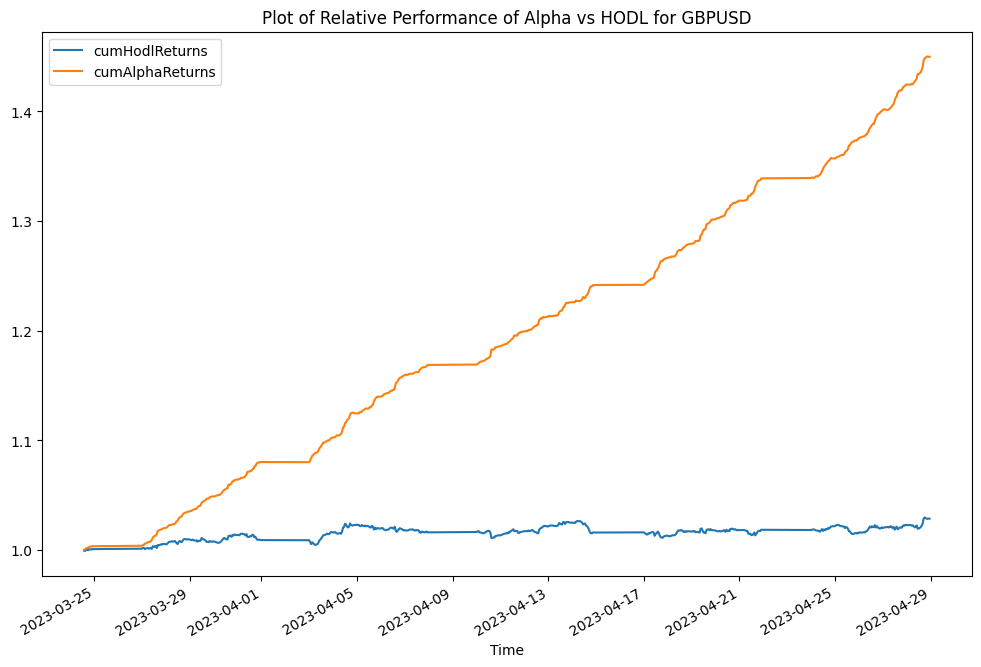

In [26]:
plotParams = ["cumHodlReturns", "cumAlphaReturns"]
result[plotParams].plot(figsize=(12,8), kind = "line", title= f"Plot of Relative Performance of Alpha vs HODL for {ticker}")
plt.show()

In [27]:
import joblib

## Save Model
model_name = "GBPUSD_LSTM_Model"
print (joblib.dump(model, model_name))

INFO:tensorflow:Assets written to: ram://9274ab1d-12c6-4af6-9d96-fe2318018139/assets
['GBPUSD_LSTM_Model']


In [29]:
## Save Predictions
result.to_csv('predictions.csv')